In [3]:
# ============================================
# CELL 1: Setup
# ============================================
!pip install -q rank_bm25 sentence-transformers scikit-learn matplotlib nltk faiss-cpu

import numpy as np
import time
import re
import logging
from dataclasses import dataclass, field
from typing import List, Dict, Tuple

import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
import faiss

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
logger = logging.getLogger("dense_vs_sparse")

STOPWORDS = set(stopwords.words('english'))

In [4]:
# ============================================
# CELL 2: Production-style tokenizer for sparse search
# (Real systems never just do .split() — this matters for BM25 quality)
# ============================================

def preprocess_text(text: str, remove_stopwords: bool = True) -> List[str]:
    """
    Production-grade tokenizer:
    - Lowercase
    - Strip punctuation/non-alphanumeric
    - Tokenize
    - Optionally remove stopwords (common words that add noise to BM25)
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = word_tokenize(text)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    return tokens


# Quick sanity check
sample = "The Error Code E-4021 occurred during checkout!"
print(preprocess_text(sample))

['error', 'code', '4021', 'occurred', 'checkout']


In [9]:
# ============================================
# CELL 3: Build a realistic mixed corpus
# (Deliberately includes both "conceptual" docs AND "exact ID" docs
#  to demonstrate where each retrieval method wins/loses)
# ============================================

corpus = [
    # Conceptual / paraphrase-friendly docs (dense should win here)
    "Our return policy allows customers to send back items within 30 days for a full refund.",
    "If you're unhappy with a purchase, you can request money back within a month of buying it.",
    "Machine learning models can automatically detect fraudulent transactions in real time.",
    "AI systems are increasingly used to flag suspicious financial activity as it happens.",
    "Employees can request remote work arrangements through the HR portal.",
    "Staff members may apply for work-from-home setups via the internal HR system.",

    # Exact-match / ID-heavy docs (sparse/BM25 should win here)
    "Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.",
    "Error code E-4099 means the shipping address failed validation. Check the ZIP code field.",
    "Product SKU-88213-A is the wireless keyboard model, currently out of stock in the US warehouse.",
    "Product SKU-88214-B is the wired keyboard model, available in all regions.",
    "Invoice #INV-2024-11837 was issued on March 3rd for account holder J. Martinez.",
    "Invoice #INV-2024-11902 was issued on March 9th for account holder R. Chen.",

    # Neutral filler docs (to make the corpus realistic)
    "The company's quarterly earnings report will be released next Thursday.",
    "New office locations are opening in Austin and Denver next quarter.",
]

logger.info(f"Corpus size: {len(corpus)} documents")

In [10]:
# ============================================
# CELL 4: Production Sparse Retriever (BM25) — wrapped in a reusable class
# ============================================

class SparseRetriever:
    """BM25-based sparse retriever with production-style structure."""

    def __init__(self, documents: List[str]):
        self.documents = documents
        self.tokenized_docs = [preprocess_text(doc) for doc in documents]
        self.bm25 = BM25Okapi(self.tokenized_docs)
        logger.info(f"SparseRetriever indexed {len(documents)} documents.")

    def search(self, query: str, top_k: int = 5) -> List[Tuple[int, float, str]]:
        tokenized_query = preprocess_text(query)
        scores = self.bm25.get_scores(tokenized_query)
        top_idx = np.argsort(scores)[::-1][:top_k]
        return [(int(i), float(scores[i]), self.documents[i]) for i in top_idx if scores[i] > 0]


sparse_retriever = SparseRetriever(corpus)

In [11]:
# ============================================
# CELL 5: Production Dense Retriever (FAISS + Sentence-Transformers)
# ============================================

class DenseRetriever:
    """Dense embedding retriever backed by FAISS, with cosine similarity via normalized dot product."""

    def __init__(self, documents: List[str], model_name: str = "all-MiniLM-L6-v2"):
        self.documents = documents
        self.model = SentenceTransformer(model_name)
        self.dim = self.model.get_embedding_dimension()

        embeddings = self.model.encode(documents, show_progress_bar=False).astype("float32")
        faiss.normalize_L2(embeddings)

        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)
        logger.info(f"DenseRetriever indexed {len(documents)} documents (dim={self.dim}).")

    def search(self, query: str, top_k: int = 5) -> List[Tuple[int, float, str]]:
        query_emb = self.model.encode([query]).astype("float32")
        faiss.normalize_L2(query_emb)
        scores, indices = self.index.search(query_emb, top_k)
        results = []
        for score, idx in zip(scores[0], indices[0]):
            if idx != -1:
                results.append((int(idx), float(score), self.documents[idx]))
        return results


dense_retriever = DenseRetriever(corpus)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [12]:
# ============================================
# CELL 6: Head-to-head comparison harness
# ============================================

def compare_retrievers(query: str, top_k: int = 3):
    print(f"\n{'='*70}\nQUERY: \"{query}\"\n{'='*70}")

    print(f"\n--- SPARSE (BM25) top-{top_k} ---")
    sparse_results = sparse_retriever.search(query, top_k)
    if not sparse_results:
        print("  (no matches — sparse requires literal term overlap)")
    for idx, score, doc in sparse_results:
        print(f"  score={score:.3f} | {doc}")

    print(f"\n--- DENSE (embeddings) top-{top_k} ---")
    dense_results = dense_retriever.search(query, top_k)
    for idx, score, doc in dense_results:
        print(f"  score={score:.3f} | {doc}")

    return sparse_results, dense_results


# TEST 1: Conceptual/paraphrased query — dense should shine
compare_retrievers("Can I get my money back after buying something?")

# TEST 2: Exact identifier query — sparse should shine, dense may confuse similar codes
compare_retrievers("What does error E-4021 mean?")

# TEST 3: Near-duplicate IDs — stress test for dense's weakness
compare_retrievers("Tell me about invoice INV-2024-11837")


QUERY: "Can I get my money back after buying something?"

--- SPARSE (BM25) top-3 ---
  score=6.423 | If you're unhappy with a purchase, you can request money back within a month of buying it.
  score=1.428 | Our return policy allows customers to send back items within 30 days for a full refund.

--- DENSE (embeddings) top-3 ---
  score=0.748 | If you're unhappy with a purchase, you can request money back within a month of buying it.
  score=0.487 | Our return policy allows customers to send back items within 30 days for a full refund.
  score=0.206 | Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.

QUERY: "What does error E-4021 mean?"

--- SPARSE (BM25) top-3 ---
  score=3.693 | Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.
  score=1.428 | Error code E-4099 means the shipping address failed validation. Check the ZIP code field.

--- DENSE (embeddings) top-3 ---
  score=0.712 | Error code E-

([(10,
   6.814850197835218,
   'Invoice #INV-2024-11837 was issued on March 3rd for account holder J. Martinez.'),
  (11,
   4.6835179532514,
   'Invoice #INV-2024-11902 was issued on March 9th for account holder R. Chen.')],
 [(11,
   0.7456709146499634,
   'Invoice #INV-2024-11902 was issued on March 9th for account holder R. Chen.'),
  (10,
   0.7174962759017944,
   'Invoice #INV-2024-11837 was issued on March 3rd for account holder J. Martinez.'),
  (6,
   0.24378730356693268,
   'Error code E-4021 indicates a payment gateway timeout. Restart the transaction to resolve it.')])

In [13]:
# ============================================
# CELL 7: Quantify the weakness — score gap between near-identical exact IDs
# (This is the core "prove it" demo for the dense-search limitation)
# ============================================

query_a = "SKU-88213-A wireless keyboard"
query_b = "SKU-88214-B wired keyboard"

dense_a = dict((doc, score) for _, score, doc in dense_retriever.search(query_a, top_k=len(corpus)))
sparse_a = dict((doc, score) for _, score, doc in sparse_retriever.search(query_a, top_k=len(corpus)))

doc_correct = "Product SKU-88213-A is the wireless keyboard model, currently out of stock in the US warehouse."
doc_wrong   = "Product SKU-88214-B is the wired keyboard model, available in all regions."

print("Query:", query_a)
print(f"\nDense similarity  -> correct doc: {dense_a.get(doc_correct, 0):.4f} | near-duplicate doc: {dense_a.get(doc_wrong, 0):.4f}")
print(f"Gap (dense):  {dense_a.get(doc_correct,0) - dense_a.get(doc_wrong,0):.4f}")

print(f"\nBM25 score        -> correct doc: {sparse_a.get(doc_correct, 0):.4f} | near-duplicate doc: {sparse_a.get(doc_wrong, 0):.4f}")
print(f"Gap (sparse): {sparse_a.get(doc_correct,0) - sparse_a.get(doc_wrong,0):.4f}")

print("\n>> Interpretation: if the dense gap is small relative to the sparse gap,")
print(">> it demonstrates dense embeddings struggle to separate near-identical IDs,")
print(">> while BM25's exact token matching cleanly distinguishes them.")

Query: SKU-88213-A wireless keyboard

Dense similarity  -> correct doc: 0.8417 | near-duplicate doc: 0.7153
Gap (dense):  0.1264

BM25 score        -> correct doc: 7.3850 | near-duplicate doc: 3.4436
Gap (sparse): 3.9414

>> Interpretation: if the dense gap is small relative to the sparse gap,
>> it demonstrates dense embeddings struggle to separate near-identical IDs,
>> while BM25's exact token matching cleanly distinguishes them.


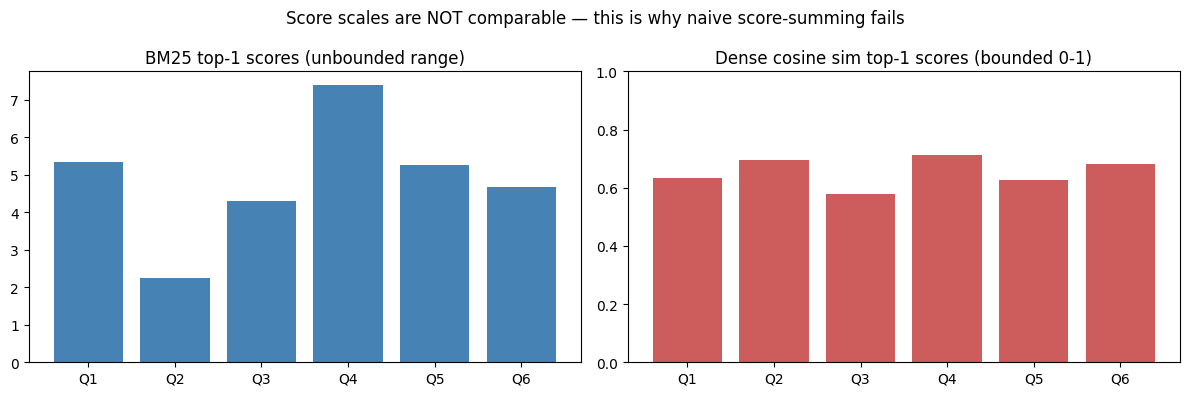

BM25 score range: 2.24 to 7.39
Dense score range: 0.58 to 0.71

>> Notice the scales are completely different — you CANNOT just add these together.
>> This exact problem is what Hybrid Search (next lesson) solves via normalization/RRF.


In [14]:
# ============================================
# CELL 8: Visualization — score distributions on the SAME query set
# (Shows why raw score fusion is invalid — sets up next lesson: Hybrid Search)
# ============================================

import matplotlib.pyplot as plt

test_queries = [
    "money back guarantee refund policy",
    "fraud detection using AI",
    "remote work from home policy",
    "error code payment timeout",
    "keyboard product stock availability",
    "invoice account holder details",
]

sparse_scores, dense_scores = [], []
for q in test_queries:
    s = sparse_retriever.search(q, top_k=1)
    d = dense_retriever.search(q, top_k=1)
    sparse_scores.append(s[0][1] if s else 0)
    dense_scores.append(d[0][1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(len(test_queries)), sparse_scores, color='steelblue')
axes[0].set_title("BM25 top-1 scores (unbounded range)")
axes[0].set_xticks(range(len(test_queries)))
axes[0].set_xticklabels([f"Q{i+1}" for i in range(len(test_queries))])

axes[1].bar(range(len(test_queries)), dense_scores, color='indianred')
axes[1].set_title("Dense cosine sim top-1 scores (bounded 0-1)")
axes[1].set_xticks(range(len(test_queries)))
axes[1].set_xticklabels([f"Q{i+1}" for i in range(len(test_queries))])
axes[1].set_ylim(0, 1)

plt.suptitle("Score scales are NOT comparable — this is why naive score-summing fails")
plt.tight_layout()
plt.show()

print("BM25 score range:", f"{min(sparse_scores):.2f} to {max(sparse_scores):.2f}")
print("Dense score range:", f"{min(dense_scores):.2f} to {max(dense_scores):.2f}")
print("\n>> Notice the scales are completely different — you CANNOT just add these together.")
print(">> This exact problem is what Hybrid Search (next lesson) solves via normalization/RRF.")